<a href="https://colab.research.google.com/github/eunbipark0223-max/Python/blob/main/MissingValues%EA%B2%B0%EC%B8%A1%EC%B9%98%EC%B2%98%EB%A6%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##환경설정

In [17]:
#구글 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

#드라이브에 저장된 폰트 등록
import matplotlib as mpl
import matplotlib.pyplot as plt #그래프 그림 그리는 모듈
import matplotlib.font_manager as fm #폰트를 관리하는 모듈

#드라이브 내 폰트 경로
font_path = '/content/drive/MyDrive/KWU/big data/dataPreProcessing/NanumGothic.ttf'

fm.fontManager.addfont(font_path)
mpl.rc('font', family='NanumGothic') #matplotlib 기본 폰트로 설정
plt.rcParams['axes.unicode_minus'] = False #마이너스 기호가 깨지지 않도록 유니코드 마이너스 비활성화

print('현재 폰트 : ', plt.rcParams['font.family'])


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
현재 폰트 :  ['NanumGothic']


In [18]:
import pandas as pd # 데이터 프레임 조작
import numpy as np # 수치 계산 및 NaN 처리
import matplotlib.pyplot as plt # 그래프 시각화
import seaborn as sns # 통계 시각화

#타이타닉 데이터 로드
titanic = pd.read_csv('/content/drive/MyDrive/KWU/big data/dataPreProcessing/train.csv')
print(titanic.shape)
titanic.head()



(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


##실습1. 결측치 특성 확인

In [23]:
# 결측치의 특성 확인
import numpy as np #np.nan 결측치 사용

print(np.nan == np.nan) # NaN은 자기 자신과도 같지 않음, 결측치 비교 불가
print(np.nan == 0) # NaN은 0이 아닌 값이 없는 상태임
print(np.nan == " ") # 공백 또한 아님


#올바른 결측치 확인 방법
print(pd.isnull(np.nan))
print(pd.notnull(np.nan))

#시리즈에서 결측치 확인
s = pd.Series([1,np.nan,3,None,5])
display(s)
print(s.isnull())






False
False
False
True
False


,0
0,1.0
1,NaN
2,3.0
3,NaN
4,5.0


0    False
1     True
2    False
3     True
4    False
dtype: bool


## 실습2 결측치 탐색

In [29]:
#기본 정보 확인
titanic.info() # Non-Null이 891 보다 작은 열에 결측치들이 존재

#열별 결측치 개수
missing_count = titanic.isnull().sum()
print(missing_count[missing_count>0])#결측치가 1개 이상인 열들만 찾기

#결측치 비율
missing_ratio = (titanic.isnull().sum() / len(titanic *100)).round(1) #결측치 수 /  전체 행 수 * 100
print(missing_ratio[missing_ratio>0])

# 전체 결측치 갯수
total_missing = titanic.isnull().sum().sum()
print(f'전체 결측치 수: {total_missing}')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
Age         177
Cabin       687
Embarked      2
dtype: int64
Age      0.2
Cabin    0.8
dtype: float64
전체 결측치 수: 866


## 실습3. 결측치 시각화 (그래프)

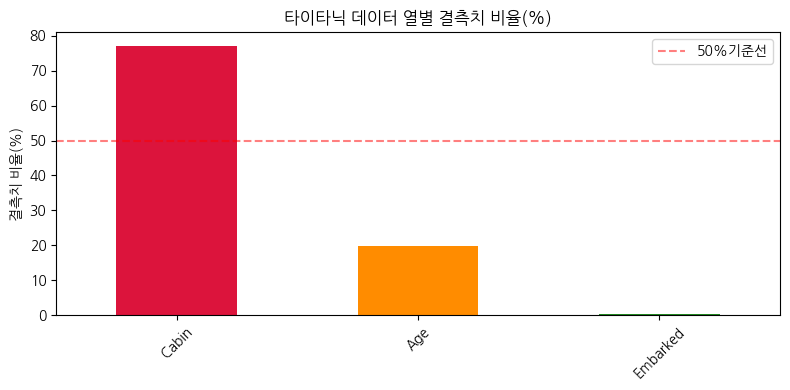

In [35]:
# 막대 그래프로 결측치 비율 시각화
missing_ratio = titanic.isnull().mean()*100
missing_ratio = missing_ratio[missing_ratio>0].sort_values(ascending=False)
missing_ratio

plt.figure(figsize = (8,4)) # 가로8인치 세로4인치 크기의 그래프 캔버스 생성
plt.title('타이타닉 데이터 열별 결측치 비율(%)')
missing_ratio.plot(kind= 'bar', color = ['#DC143C', '#FF8C00','#228B22'])
plt.ylabel('결측치 비율(%)')
plt.xticks(rotation = 45) # x축 눈금 레이블을 45도 기울여서
plt.axhline(y=50, color ='red' , linestyle = '--',alpha = 0.5, label = '50%기준선')
plt.legend() # 범례 표시 (빨간 점선)
plt.tight_layout()# 그래스 요소들이 겹치지 않도록 자동으로 여백 조정
plt.show()#그래프를 화면에 출력


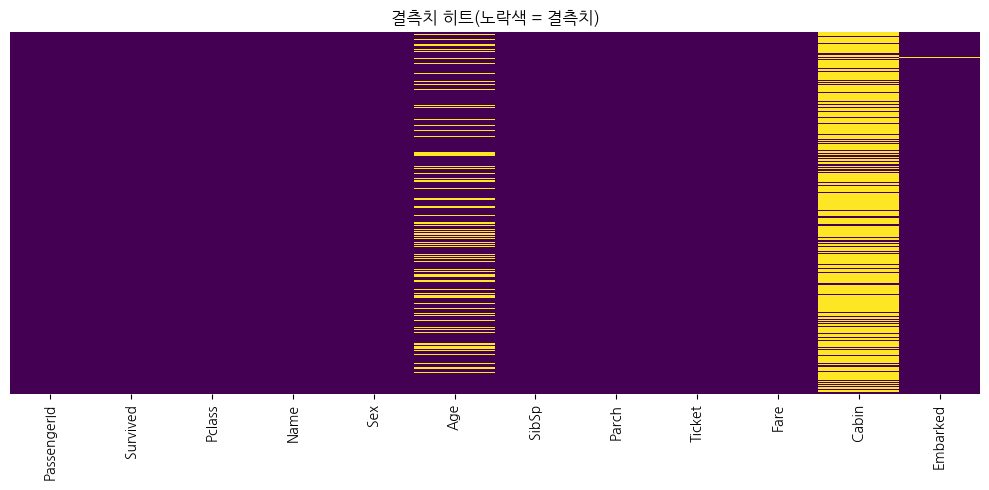

In [36]:
# 히트맵으로 결측치 패턴 시각화
plt.figure(figsize = (10,5))
sns.heatmap(titanic.isnull(),
            cmap = 'viridis', # 색상 테마 : 노란색(결측치 = True) / 보라색(결측치 = False)
            cbar = False,
            yticklabels = False) # y축 행 번호는 지움
plt.title('결측치 히트(노락색 = 결측치)')
plt.tight_layout()
plt.show()

##실습4. 결측치 대체 - fillna( )
결측치 채워 넣기

In [42]:
#고정값으로 대체: 범주형 열
print(titanic['Embarked'].mode()) #최빈값
titanic['Embarked'].fillna('S')
titanic['Age'].fillna(0)

#통계값으로 대체: 수치형 열
mean_age = titanic["Age"].mean()
median_age = titanic["Age"].median()
print(mean_age, median_age)

titanic['Age_filled'] = titanic['Age'].fillna(median_age)

# 대체 전후 비교
print('대체 전 결측치:', titanic['Age'].isnull().sum())
print('대체 후 결측치:', titanic['Age_filled'].isnull().sum())

#그룹별 동계값으로 대체: 더 정밀한 방법 고민
#성별 / 등급별 중앙값으로 나이 대체
titanic['Age_group_filled'] = titanic.groupby(['Sex', 'Pclass'])['Age'].transform(
    lambda x: x.fillna(x.median())
)  # transform()은 그룹 연산 결과를 원본과 같은 크기의Series로 변환

print(titanic.groupby(['Sex','Pclass'])['Age'].median())

0    S
Name: Embarked, dtype: object
29.69911764705882 28.0
대체 전 결측치: 177
대체 후 결측치: 0
Sex     Pclass
female  1         35.0
        2         28.0
        3         21.5
male    1         40.0
        2         30.0
        3         25.0
Name: Age, dtype: float64


## 실습5. 결측치 대체 - 방향성 채우기

In [48]:
#시계열 데이터 예시: 날짜별 탑승객 수
daily_passengers = pd.Series(
    [100,np.nan, np.nan, 130, np.nan, 150],
    index = pd.date_range('2026-01-01',periods = 6)
)
print('원본:\n',daily_passengers)

#정방향으로 채우기 (ffill = forwardfill): 결측치를 바로 앞의 유효한 값으로 채움
print('\n ffill: \n', daily_passengers.ffill())

#역방향 채우기 (bfill = backwardfill): 결측치를 바로 뒤의 유효한 값으로 채움
print('\n bfill: \n',daily_passengers.bfill())

#보간법(interpoiate): 앞뒤 값 사이를 선형으로 계산해서 채움
print('\n interpoiate: \n', daily_passengers.interpolate())

# 시리즈 맨 첫 값이 NaN 이면 ffill로 채울 수 없음
s = pd.Series([np.nan, 2, np.nan, 4])
print(s.ffill()) #첫번째 nan은 그대로 nan값

원본:
 2026-01-01    100.0
2026-01-02      NaN
2026-01-03      NaN
2026-01-04    130.0
2026-01-05      NaN
2026-01-06    150.0
Freq: D, dtype: float64

 ffill: 
 2026-01-01    100.0
2026-01-02    100.0
2026-01-03    100.0
2026-01-04    130.0
2026-01-05    130.0
2026-01-06    150.0
Freq: D, dtype: float64

 bfill: 
 2026-01-01    100.0
2026-01-02    130.0
2026-01-03    130.0
2026-01-04    130.0
2026-01-05    150.0
2026-01-06    150.0
Freq: D, dtype: float64

 interpoiate: 
 2026-01-01    100.0
2026-01-02    110.0
2026-01-03    120.0
2026-01-04    130.0
2026-01-05    140.0
2026-01-06    150.0
Freq: D, dtype: float64
0    NaN
1    2.0
2    2.0
3    4.0
dtype: float64


##실습6. 결측치 삭제 - dropna( )
결측치가 하나라도 있는 행 모두 삭제

In [53]:
# dropna(): 결측치가 하나라도 있는 행 모두 삭제
df_dropped = titanic.dropna()
print(f'원본:{titanic.shape}')
print(f'dropna 후 :{df_dropped.shape}')

#열 삭제: 결측치 비율이 매우 높은 열은 행 삭제 대신 열 자체를 제거하는 것이 효과적
df_no_deck = titanic.drop(columns=['Cabin'])
print(f'df_no_deck: {df_no_deck.shape}')

#subset 옵션: 특정 열에 결측치가 있는 행만 삭제
df_age_only = titanic.dropna(subset=['Age'])
print(f'age 기준 dropna: {df_age_only.shape}')

#how = 'all'옵션: 모든 열이 전부 NaN인 행만 삭제
df_all = titanic.dropna(how='all')
print(f'df_all:{df_all.shape}')

# thresh옵션: 유효값(NaN이 아닌 값) 개수가 thresh 임계점 미만인 행 삭제
df_thresh = titanic.dropna(thresh = 10) #유효값이 10개 미만인 행 삭제(열)
print(f'df_thresh: {df_thresh.shape}')



원본:(891, 14)
dropna 후 :(183, 14)
df_no_deck: (891, 13)
age 기준 dropna: (714, 14)
df_all:(891, 14)


## 실습7. 결측치가 있는 상태로 계산

In [56]:
#결측치가 포함된 사칙연산 : 결측치와의 연산 결과는 항상 NaN
s = pd.Series([10,np.nan,30,np.nan,50])
print( s + 5)

#집게 함수(sum, mean 등)는 기본적으로 NaN을 무시하고 계산
print(s.sum())
print(s.mean())

#skipna = False로 설정하면 NaN이 하나라도 있으면 결과도 NaN\
print(s.sum(skipna=False))

#타이타닉: 결측치 없는 열끼리 더하면 정산 계산
titanic['FamilySize'] = titanic['SibSp'] +titanic['Parch']

#타이타닉: 결측치 있는 열과의 연산
titanic['Test'] = titanic['Age'] + titanic['Fare']
print(titanic['Test'].isnull().sum())

titanic = titanic.drop(colums = ['Test'])



0    15.0
1     NaN
2    35.0
3     NaN
4    55.0
dtype: float64
90.0
30.0
nan

177


##np.NaN vs pd.Na 비교


In [66]:
#np.NaN을 정수 옆에 삽입하면 열 전체가 float으로 자동 변환됨
df = pd.DataFrame({'name':['Alice', 'Bob'],'age':[25,30]})
df.loc[0,'age'] = np.nan
print(df.dtypes)
print(df)

#pd.Na + nullable integer(Int64)를 사용하면 정수 타입 유지 가능
df2 = pd.DataFrame({'name':['Alice', 'Bob'],'age':pd.array([25,30],dtype='Int64')})
df.loc[0,'age'] = pd.NA
print(df2.dtypes)
print(df2)

#np.nan vs pd.NA 논리 연산 차이
print(True and np.nan)
print(False and np.nan)

print(True and pd.NA) #결과 불확실
print(False and pd.NA)

#실무에서 결측치 여부는 항상 isnull() 또는 isna() 사용
print(pd.isnull(np.nan))
print(pd.isna(pd.NA))


name     object
age     float64
dtype: object
    name   age
0  Alice   NaN
1    Bob  30.0
name    object
age      Int64
dtype: object
    name  age
0  Alice   25
1    Bob   30
nan
False
<NA>
False
True
True


## 타이타닉 결측치 전처리

In [68]:
titanic_clean = titanic.copy()

#Cabin 열 삭제
titanic_clean = titanic_clean.drop(columns =['Cabin'])

#Age 결측치 처리
titanic_clean['Age'] = titanic_clean.groupby(['Sex','Pclass'])['Age'].transform(lambda x: x.fillna(x.median()))

#Embarked 결측치 처리
titanic_clean['Embarked'] = titanic_clean['Embarked'].fillna(titanic_clean['Embarked'].mode()[0])

#최종 결측치 현황 확인
print("전처리 후 결측치:")
print(titanic_clean.isnull().sum()[titanic_clean.isnull().sum()>0])

print(f'\n 원본 shape: {titanic.shape}')
print(f'전처리 후 shape:{titanic_clean.shape}')




전처리 후 결측치:
Test    177
dtype: int64

 원본 shape: (891, 16)
전처리 후 shape:(891, 15)


In [73]:
#Age가 결측인 승객만 필터링해서 결측치 발생 패턴 분석
age_missing = titanic[titanic['Age'].isnull()]
age_missing [['SibSp','Parch','Sex','Pclass']]

#수치형 열 분포 요약 통계
age_missing [['SibSp','Parch','Sex','Pclass']].describe()

print(age_missing['Sex'].value_counts())
print(age_missing['Pclass'].value_counts())
print(age_missing['SibSp'].value_counts())
print(age_missing['Parch'].value_counts())

Sex
male      124
female     53
Name: count, dtype: int64
Pclass
3    136
1     30
2     11
Name: count, dtype: int64
SibSp
0    137
1     26
8      7
3      4
2      3
Name: count, dtype: int64
Parch
0    157
2     12
1      8
Name: count, dtype: int64


##위 분석 결과 요약

*   Sex: male이 압도적으로 많음 -> 나이 기재를 생략한 승객 대부분이 남성
*   Pclass: 3등석이 가장 많음 -> 저가 티켓 승객일수록 개인정보 누락 가능성 높음
*   SibSp / Parch: 0이 대부분 -> 가족 없이 혼자 탑승한 승객에서 결측치가 많이 발생


In [72]:
#특정 조건 (혼자 탑승한 3등석 남성)에 해당하는 그룹의 평균 나이 계산

condition = (
    (titanic['Sex'] == 'male') &
    (titanic['Pclass'] == 3) &
    (titanic['SibSp'] == 0) &
    (titanic['Parch'] == 0)
)
group_mean_age = titanic[condition]['Age'].mean()

In [ ]:
#위 조건을 만족하면서 동시에 Age가 결측인 행에만 평균 나이를 채움
 titanic.loc[condition & titanic['Age'].isnull(), 'Age'] = group_mean_age